In [1]:
import utils
import importlib
importlib.reload(utils);

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from scipy.stats import entropy

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

# Lo primero que debo hacer es iportar el dataset
GEDEvent_path = './GEDEvent_v25_1.csv'
df_GEDEvent = pd.read_csv(GEDEvent_path)

# Resumen de datos: Tipo y cantidad de faltantes.
resumen_df = pd.DataFrame({
    'Tipo de dato':     df_GEDEvent.dtypes,
    'Valores faltantes': df_GEDEvent.isnull().sum(),
    '% Faltantes':      (df_GEDEvent.isnull().sum() / len(df_GEDEvent) * 100).round(2)
})

resumen_df

C:\Users\santi\AppData\Local\Temp\ipykernel_21808\3189389306.py:14: DtypeWarning: Columns (0: gwnoa) have mixed types. Specify dtype option on import or set low_memory=False.
  df_GEDEvent = pd.read_csv(GEDEvent_path)


,Tipo de dato,Valores faltantes,% Faltantes
id,int64,0,0.00
relid,str,0,0.00
year,int64,0,0.00
active_year,bool,0,0.00
code_status,str,0,0.00
type_of_violence,int64,0,0.00
conflict_dset_id,int64,0,0.00
conflict_new_id,int64,0,0.00
conflict_name,str,0,0.00
dyad_dset_id,int64,0,0.00


In [4]:
# Buscar Argentina en la columna country
argentina = df_GEDEvent[df_GEDEvent['country'].str.contains('Argentina', case=False, na=False)]

print(f"Registros con Argentina: {len(argentina)}")

if len(argentina) > 0:
    print("\nDetalle de eventos:")
    print(argentina[['year', 'type_of_violence', 'conflict_name', 
                      'side_a', 'side_b', 'best', 'region']].to_string())

Registros con Argentina: 2

Detalle de eventos:
       year  type_of_violence             conflict_name                side_a     side_b  best    region
48517  1992                 1  Israel: Southern Lebanon  Government of Israel  Hezbollah     0  Americas
48518  1994                 3     Hezbollah - Civilians             Hezbollah  Civilians    86  Americas


In [5]:
paises = df_GEDEvent['country'].unique()
print(f"Cantidad de países distintos: {len(paises)}")
print("\nListado completo:")
print(sorted(paises))

Cantidad de países distintos: 124

Listado completo:
['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Belgium', 'Benin', 'Bhutan', 'Bolivia', 'Bosnia-Herzegovina', 'Botswana', 'Brazil', 'Burkina Faso', 'Burundi', 'Cambodia (Kampuchea)', 'Cameroon', 'Canada', 'Central African Republic', 'Chad', 'China', 'Colombia', 'Comoros', 'Congo', 'Croatia', 'DR Congo (Zaire)', 'Djibouti', 'Ecuador', 'Egypt', 'El Salvador', 'Eritrea', 'Ethiopia', 'France', 'Gambia', 'Georgia', 'Germany', 'Ghana', 'Guatemala', 'Guinea', 'Guinea-Bissau', 'Guyana', 'Haiti', 'Honduras', 'India', 'Indonesia', 'Iran', 'Iraq', 'Israel', 'Italy', 'Ivory Coast', 'Jamaica', 'Jordan', 'Kenya', 'Kingdom of eSwatini (Swaziland)', 'Kuwait', 'Kyrgyzstan', 'Laos', 'Lebanon', 'Lesotho', 'Liberia', 'Libya', 'Madagascar (Malagasy)', 'Malaysia', 'Mali', 'Malta', 'Mauritania', 'Mexico', 'Moldova', 'Morocco', 'Mozambique', 'Myanmar (Burma)', 'Namibia',

#### _Datos Faltantes_

* __"source_office", "source_date" y "source_headline"__: el codebook nos dá un explicación. Estos campos fueron cargados a partir del año 2013, todo lo anterior no tiene información.
* __"source_original"__: Muchas veces está en blanco debido a que quien recogió los datos no pudo identificar a la fuente de información
* __"where_description"__: Fue deprecada en versiones actuales, por lo que no está sujeta a análisis
* __"adm_1 y adm_2"__: Se refieren al lugar principal (Provincia) y al secundario (Distrito) donde ocurre el evento. Puede ser que si el conflicto implica muchos lugares al mismo tiempo, el dato no se haya cargado
* __"gwnoa y gwnob"__: Denotan cuando el bando A o el B son estados, si alguno no lo es, el dato estará vacío.


#### _Datos Deprecados_

Según el codebook, algunas de las columnas que se agregaron en versiones anteriores del archivo ya no son utilizados, por ende, para no entorpecer el análisis, voy a sacarlas. 
Estas son: where_description, relid, conflict_dset_id, dyad_dset_id, side_a_dset_id, side_b_dset_id

In [4]:
# Voy a quitar las columnas mencionadas anteriormente
col2drop = ['id', 'where_description', 'relid', 'conflict_dset_id', 'dyad_dset_id', 'side_a_dset_id', 'side_b_dset_id']
df_GEDEvent = df_GEDEvent.drop(columns=col2drop)
df_GEDEvent.info()

<class 'pandas.DataFrame'>
RangeIndex: 385918 entries, 0 to 385917
Data columns (total 42 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   year               385918 non-null  int64  
 1   active_year        385918 non-null  bool   
 2   code_status        385918 non-null  str    
 3   type_of_violence   385918 non-null  int64  
 4   conflict_new_id    385918 non-null  int64  
 5   conflict_name      385918 non-null  str    
 6   dyad_new_id        385918 non-null  int64  
 7   dyad_name          385918 non-null  str    
 8   side_a_new_id      385918 non-null  int64  
 9   side_a             385918 non-null  str    
 10  side_b_new_id      385918 non-null  int64  
 11  side_b             385918 non-null  str    
 12  number_of_sources  385918 non-null  int64  
 13  source_article     385917 non-null  str    
 14  source_office      288005 non-null  str    
 15  source_date        288005 non-null  str    
 16  source_headli

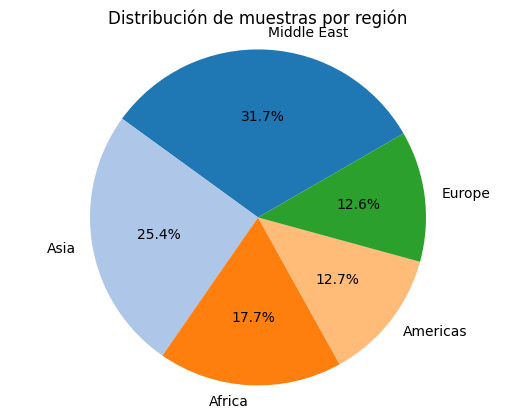

In [5]:
# Voy a mostrar en un gráfico de torta el porcentaje de ocurrencia de la locación de los conflictos (Donde hay mas conflictos)
region_count = df_GEDEvent['region'].value_counts()
colors = sns.color_palette('tab20', len(region_count))
plt.pie(region_count.values, 
        labels=region_count.index,
        autopct='%1.1f%%',
        colors=colors,
        startangle=30)

plt.title('Distribución de muestras por región')
plt.axis('equal')
plt.show()

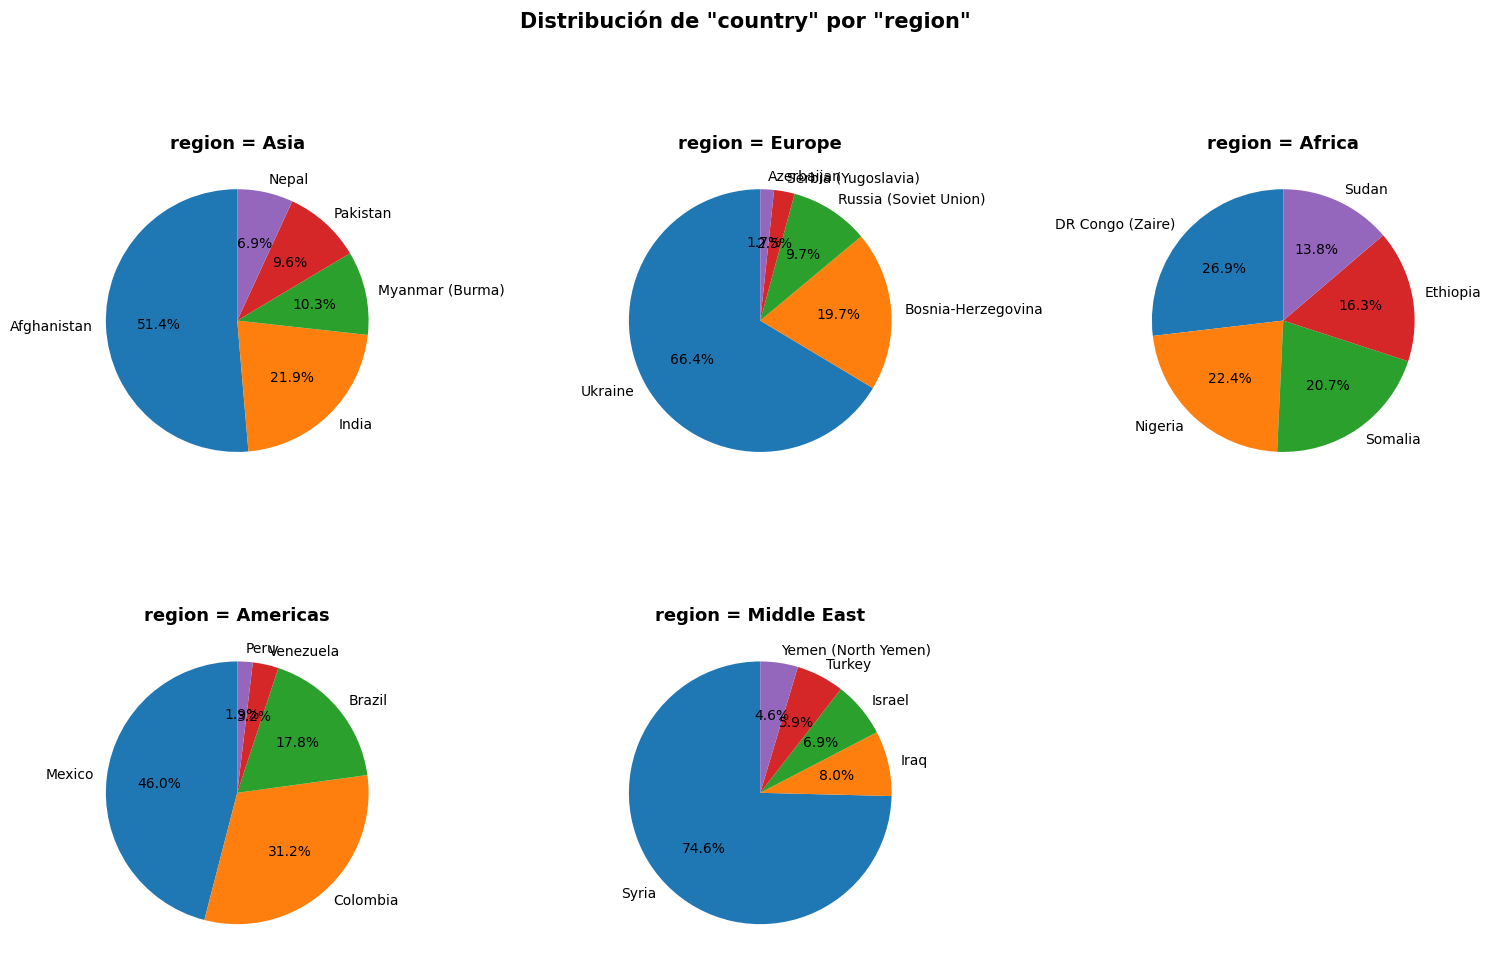

In [6]:
# Ahora voy a graficar en mútiples gráficos de torta la ocurrencia de conflictos en 
# los distintos paises filtrado por región.
utils.graficos_torta_por_categoria(df=df_GEDEvent, col_filtro='region', col_distribucion='country', n_first=5, cols=3)

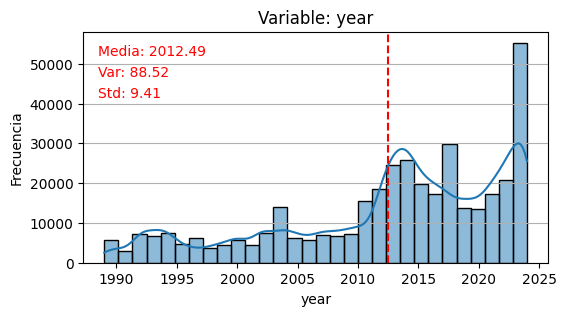

El año con mayor cantidad de conflictos es el 2024 con un total de 28816 conflictos


In [7]:
# Ahora voy a graficar la ocurrencia de conflictos de acuerdo al año. 
# Con el siguiente gráfico podremos ver en que año hubo mas conflicto
utils.plot_histograma(df_GEDEvent, 'year', bins=30)
print('El año con mayor cantidad de conflictos es el', df_GEDEvent['year'].mode()[0], 'con un total de', np.max(df_GEDEvent['year'].value_counts()), 'conflictos')

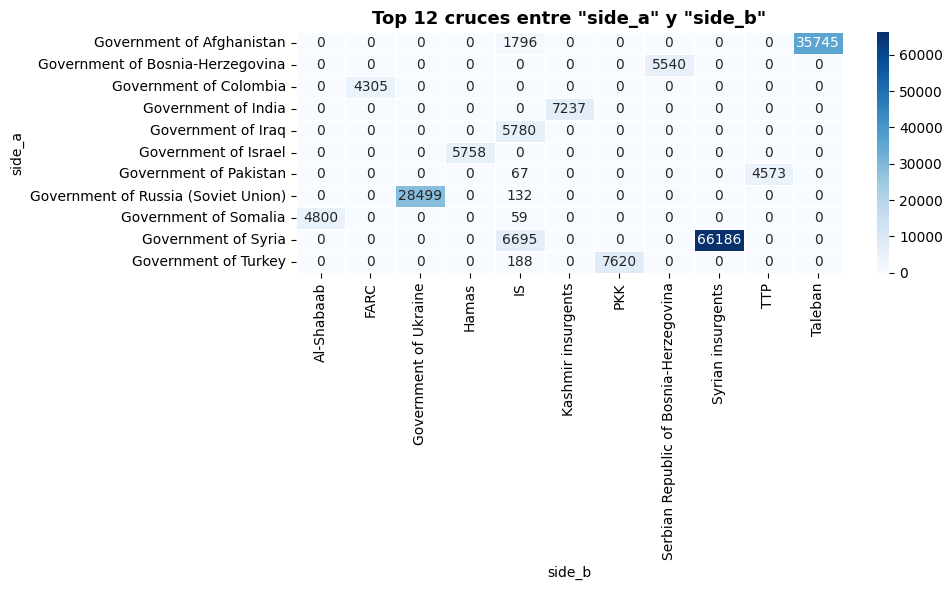

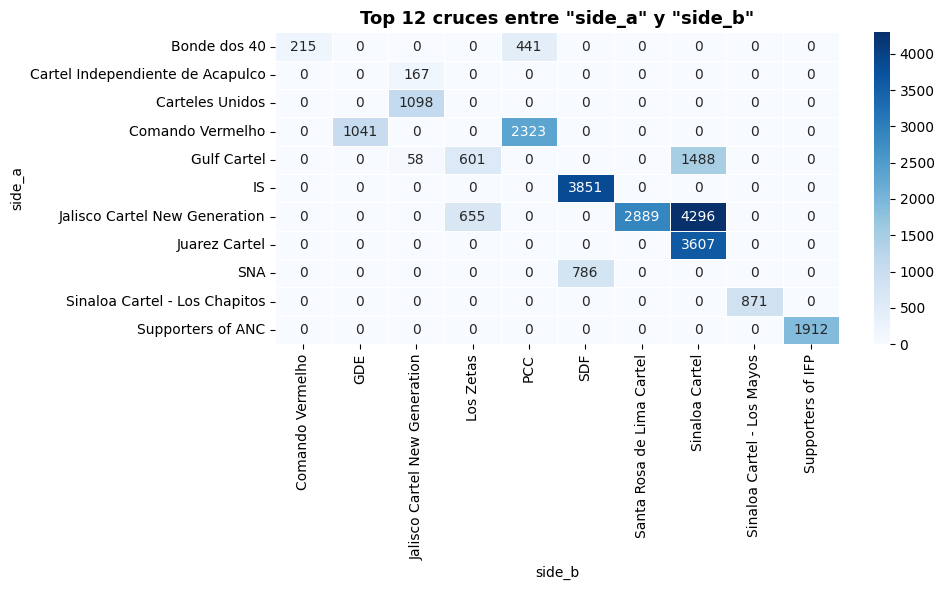

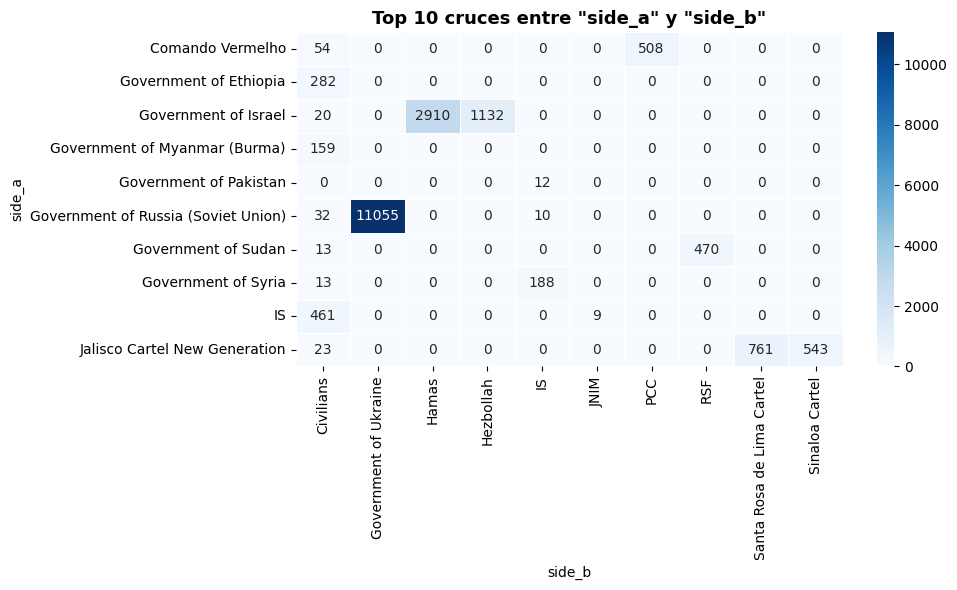

In [8]:
conflict_type = [1, 2, 3]
df_st  = df_GEDEvent[df_GEDEvent['type_of_violence'] == conflict_type[0]].drop(columns='type_of_violence')
df_nst = df_GEDEvent[df_GEDEvent['type_of_violence'] == conflict_type[1]].drop(columns='type_of_violence')
df_os  = df_GEDEvent[df_GEDEvent['type_of_violence'] == conflict_type[2]].drop(columns=['type_of_violence', 'side_b'])

utils.heatmap_contingencia(df_st, 'side_a', 'side_b', n=12)
utils.heatmap_contingencia(df_nst, 'side_a', 'side_b', n=12)

# Tomando solo el año 2024, voy a ver donde se da la mayor cantidad de cruce,
# es decir, entre que dos facciones hubo mas conflictos
df_GEDE_max_year = df_GEDEvent[df_GEDEvent['year'] == 2024]
# Para ellos voy a utilizar un heatmap y solo voy a utilizar los 10 valores mas frecuentes,
# ya que si usase todo los valores, el gráfico sería gigantesco
utils.heatmap_contingencia(df_GEDE_max_year, 'side_a', 'side_b', n=10)

### Definición de Clasificador (Variable Target)

Voy a definir un calsificador a partir el número de muertes, el cual será mi variable target. 
Los límites que voy a imponer serán de 0 (No hubo muertes), 10, 100, 1000, 10000 y +10000

In [9]:
# Con la siguiente función voy a identificar el tipo de conflicto 
# en base a la cantidad de muertes.
def clasificar_gravedad(muertes):
    # Si no hay víctimas confirmadas (best = 0)
    if muertes == 0:
        return 0  
    # Si la cantidad de muertes es muy baja (0 < best <= 10)
    elif muertes <= 10:
        return 1
    # Si la cantidad de muertes es baja (10 < best <= 100)
    elif muertes <= 100:
        return 2
    # Si la cantidad de muertes es moderada (100 < best <= 1000)
    elif muertes <= 1000:
        return 3
    # Si la cantidad de muertes es Alta (1000 < best <= 10000)
    elif muertes <= 10000:
        return 4
    # Si la cantidad de muertes es mayor a 10000 el conflicto fue catastrófico
    else:
        return 5  # Catastrófico

# A la columna "best(Cantidad total de muertes)" le aplico la función 
# definida anteriormente y el resultado lo agrego dentro de la columna "gravedad"
df_GEDEvent['gravedad'] = df_GEDEvent['best'].apply(clasificar_gravedad)
print(df_GEDEvent['gravedad'].value_counts().sort_index())

gravedad
0     30021
1    315543
2     37630
3      2460
4       233
5        31
Name: count, dtype: int64


### Tratamiento de datos redundates

Una vez que tengo el clasificador, tengo que quitar del dataset todas las variables que están intimamente relacionadas con el mismo, las cuales pueden sesgar todo mi análisis.

In [10]:
# Voy a quitar del dataframe todas aquellas columnas que dan una idea o están
# relacionadas con la columna que cree en el paso anterior
death_cols = [
    'deaths_a',          # muertes del actor A
    'deaths_b',          # muertes del actor B
    'deaths_civilians',  # muertes civiles
    'deaths_unknown',    # muertes sin clasificar
    'best',              # estimación central de muertes totales
    'low',               # estimación mínima
    'high'               # estimación máxima
]

# Creo un nuevo dataset sin estas columnas
df_GEDEvent_model = df_GEDEvent.drop(columns=death_cols)

In [11]:
# Si reviso cuales son las columnas de mi dataframe, ahora voy a ver la nueva feature "gravedad"
print(df_GEDEvent_model.columns.tolist())
print(df_GEDEvent_model.shape)

['year', 'active_year', 'code_status', 'type_of_violence', 'conflict_new_id', 'conflict_name', 'dyad_new_id', 'dyad_name', 'side_a_new_id', 'side_a', 'side_b_new_id', 'side_b', 'number_of_sources', 'source_article', 'source_office', 'source_date', 'source_headline', 'source_original', 'where_prec', 'where_coordinates', 'adm_1', 'adm_2', 'latitude', 'longitude', 'geom_wkt', 'priogrid_gid', 'country', 'country_id', 'region', 'event_clarity', 'date_prec', 'date_start', 'date_end', 'gwnoa', 'gwnob', 'gravedad']
(385918, 36)


Seguido de ello, voy a eliminar todas las columnas que no quiero utilizar en el análisis, ya sea porque no me aportan ninguna información/no son relevantes. 

También voy a calcular la información mutua del resto de las variables para saber si en esta altura puedo eliminar alguna

In [12]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# Columnas de texto libre — descarte directo sin test
text_cols = [
    'source_article', 'source_office', 'source_date', 'source_headline',
    'source_original', 'where_coordinates',
    'geom_wkt', 'conflict_name', 'dyad_name', 'side_a', 'side_b',
    'adm_1', 'adm_2'
]

df_GEDEvent_model = df_GEDEvent_model.drop(columns = text_cols)

# Columnas a testear (identificadores y redundantes incluidos)
cols_to_test = [
    'year', 'active_year', 'code_status', 'type_of_violence',
    'conflict_new_id', 'dyad_new_id',
    'side_a_new_id', 'side_b_new_id',
    'number_of_sources', 'where_prec', 'latitude', 'longitude',
    'priogrid_gid', 'country_id', 'region', 'event_clarity',
    'date_prec', 'gwnoa', 'gwnob', 'country'
]

# Preparar dataframe para el test
df_test = df_GEDEvent_model[cols_to_test].copy()

# Encodear columnas categóricas/object de forma más robusta
le = LabelEncoder()
for col in df_test.columns:
    # Convertir todo a string primero, luego encodear
    df_test[col] = df_test[col].fillna('desconocido')
    df_test[col] = le.fit_transform(df_test[col].astype(str))

# Calcular información mutua
y = df_GEDEvent_model['gravedad']
mi_scores = mutual_info_classif(df_test, y, random_state=42)

# Mostrar resultados ordenados
mi_results = pd.Series(mi_scores, index=cols_to_test).sort_values(ascending=False)
print(mi_results.round(4))

longitude            0.0987
dyad_new_id          0.0981
latitude             0.0961
priogrid_gid         0.0958
conflict_new_id      0.0944
gwnob                0.0769
side_b_new_id        0.0764
side_a_new_id        0.0722
country              0.0653
country_id           0.0650
active_year          0.0644
gwnoa                0.0559
region               0.0393
number_of_sources    0.0210
date_prec            0.0180
year                 0.0157
event_clarity        0.0134
where_prec           0.0117
type_of_violence     0.0074
code_status          0.0002
dtype: float64


### Creación de Features

Voy a crear dos nuevos features, uno que me indique cual fue la duración del conflicto y otro que me indique la frecuencia con la que ocurre

In [13]:
drop_cols = [
    'code_status', # Score 0 — sin información
    'country_id',  # 0.0638 — redundante con country (0.0656)
    'gwnoa',       # 0.0566 — redundante con side_a_new_id
    'gwnob',       # 0.0764 — redundante con side_b_new_id
]

df_GEDEvent_model = df_GEDEvent_model.drop(columns = drop_cols)

keep_cols = [
    'longitude',          # 0.0994
    'dyad_new_id',        # 0.0975
    'latitude',           # 0.0965
    'priogrid_gid',       # 0.0954
    'conflict_new_id',    # 0.0954
    'side_b_new_id',      # 0.0772
    'side_a_new_id',      # 0.0726
    'country',            # 0.0656
    'active_year',        # 0.0626
    'region',             # 0.0387
    'number_of_sources',  # 0.0218
    'date_prec',          # 0.0183
    'year',               # 0.0144
    'event_clarity',      # 0.0135
    'where_prec',         # 0.0123
    'type_of_violence',   # 0.0072
]

# Creo una nueva columna que me indique cual fue la duración del conflicto
# Para ello hago la diferencia entre la fecha de fin y la fecha de inicio
df_GEDEvent_model['duracion_dias'] = (
    pd.to_datetime(df_GEDEvent_model['date_end']) - pd.to_datetime(df_GEDEvent_model['date_start'])
).dt.days

# Saco las columnas "date_end" y "date_start" ya que no las voy a necesitar
df_GEDEvent_model = df_GEDEvent_model.drop(columns = ['date_start', 'date_end'])

# 
df_GEDEvent_model['frecuencia_conflicto'] = df_GEDEvent_model.groupby('conflict_new_id')['conflict_new_id'].transform('count')

### Tratamiento de Nulos

Debo fijarme si me quedó algún nulo en las columnas restantes, ya que de ser así, debo tratarlo.

In [14]:
# Columnas las cuales quiero observar
cols_final = [
    'longitude', 'dyad_new_id', 'latitude', 'priogrid_gid',
    'conflict_new_id', 'side_b_new_id', 'side_a_new_id', 'country',
    'active_year', 'region', 'number_of_sources', 'date_prec',
    'year', 'event_clarity', 'where_prec', 'type_of_violence',
    'duracion_dias', 'frecuencia_conflicto'
]

# Hago el recuento de nulos columna a columna y calculo el porcentaje
nulos = df_GEDEvent_model[cols_final].isnull().sum()
porcentaje = (nulos / len(df_GEDEvent_model) * 100).round(2)

# Pongo todos los datos en un Dataframe para que la visulización sea
# amena
resumen_nulos = pd.DataFrame({
    'nulos': nulos,
    'porcentaje': porcentaje,
    'dtype': df_GEDEvent_model[cols_final].dtypes
}).sort_values('porcentaje', ascending=False)

print(resumen_nulos)

                      nulos  porcentaje    dtype
longitude                 0         0.0  float64
dyad_new_id               0         0.0    int64
latitude                  0         0.0  float64
priogrid_gid              0         0.0    int64
conflict_new_id           0         0.0    int64
side_b_new_id             0         0.0    int64
side_a_new_id             0         0.0    int64
country                   0         0.0      str
active_year               0         0.0     bool
region                    0         0.0      str
number_of_sources         0         0.0    int64
date_prec                 0         0.0    int64
year                      0         0.0    int64
event_clarity             0         0.0    int64
where_prec                0         0.0    int64
type_of_violence          0         0.0    int64
duracion_dias             0         0.0    int64
frecuencia_conflicto      0         0.0    int64


### Codficacion de Variables Categóricas

Voy a codificar todas las variables categóricas para facilitar el análisis. Algunas como "conflict_new_id" tienen muchos valores posibles, lo cual puede ser problemático, por ejemplo, luego de hacer el split, algunos valores "unicos" pueden quedar en el conjunto de test. Es importante evitar esto ya que el modelo puede tener un comportamiento equívoco cuando se lo testea con un dato con el cual nunca se lo entrenó

In [ ]:
# Hago un label encoding para la region, son pocas regiones fijas y bien definidas, 
# no van a aparecer regiones nuevas en test.
region_map = {
    'Africa': 0,
    'Americas': 1,
    'Asia': 2,
    'Europe': 3,
    'Middle East': 4
}
df_GEDEvent_model['region'] = df_GEDEvent_model['region'].map(region_map)

# Voy a hacer un frequency encoding para 'country', en lugar de un label arbitrario
# le asignamos a cada país su cantidad histórica de evento.
freq_country = df_GEDEvent_model.groupby('country').size()
df_GEDEvent_model['country'] = df_GEDEvent_model['country'].map(freq_country)

# Las variables 'side_a_new_id' y 'side_a_new_id' voy a encodearlas
# de acuerdo a su frecuencia de aparición
for col in ['side_a_new_id', 'side_b_new_id']:
    freq = df_GEDEvent_model.groupby(col).size()
    df_GEDEvent_model[col] = df_GEDEvent_model[col].map(freq)

# Algo parecido voy a hacer con 'conflict_new_id' y 'dyad_new_id'
# voy a indicar que tan largo es el conflicto
for col in ['conflict_new_id', 'dyad_new_id']:
    duracion = df_GEDEvent_model.groupby(col)['year'].transform(lambda x: x.max() - x.min())
    df_GEDEvent_model[col] = duracion

# Por último, voy a 'priogrid_gid' y a asignarle un valor 
# de acuerdo a si la zona es historicamente conlfictiva
freq_grid = df_GEDEvent_model.groupby('priogrid_gid').size()
df_GEDEvent_model['priogrid_gid'] = df_GEDEvent_model['priogrid_gid'].map(freq_grid)

### Separar en Train y Test

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Voy a separar X (features) y Y (Target) para poder
# separar el dataframe en train y test.
X = df_GEDEvent_model[cols_final]
y = df_GEDEvent_model['gravedad']

# La proporción que voy a usar para test será de 20%
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Imprimo cual fue el resultado, mas que nada para saber
# cual fue la distribución de la variable target en el conjunto de test
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("\nDistribución en train:")
print(y_train.value_counts().sort_index())
print("\nDistribución en test:")
print(y_test.value_counts().sort_index())

Train: (308734, 18), Test: (77184, 18)

Distribución en train:
gravedad
0     24017
1    252434
2     30104
3      1968
4       186
5        25
Name: count, dtype: int64

Distribución en test:
gravedad
0     6004
1    63109
2     7526
3      492
4       47
5        6
Name: count, dtype: int64


### Estandarización de datos

Ahora que todos mis datos son numéricos, tengo que aplicar la estandarización para poder trabajar con ellos. Recordemos que si no hacemos esto, el modelo entrenado puede enfrentarse con valores inesperados cuando se le aplica el set de testeo

In [ ]:
numeric_cols = [
    # Originalmente numéricas
    'latitude', 'longitude', 'number_of_sources', 
    'year', 'duracion_dias', 'frecuencia_conflicto',
    'where_prec', 'date_prec', 'event_clarity',
    'active_year',
    
    # Recién convertidas a numéricas
    'region', 'country', 'priogrid_gid',
    'side_a_new_id', 'side_b_new_id',
    'conflict_new_id', 'dyad_new_id'
]

scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

### Visualización de datos

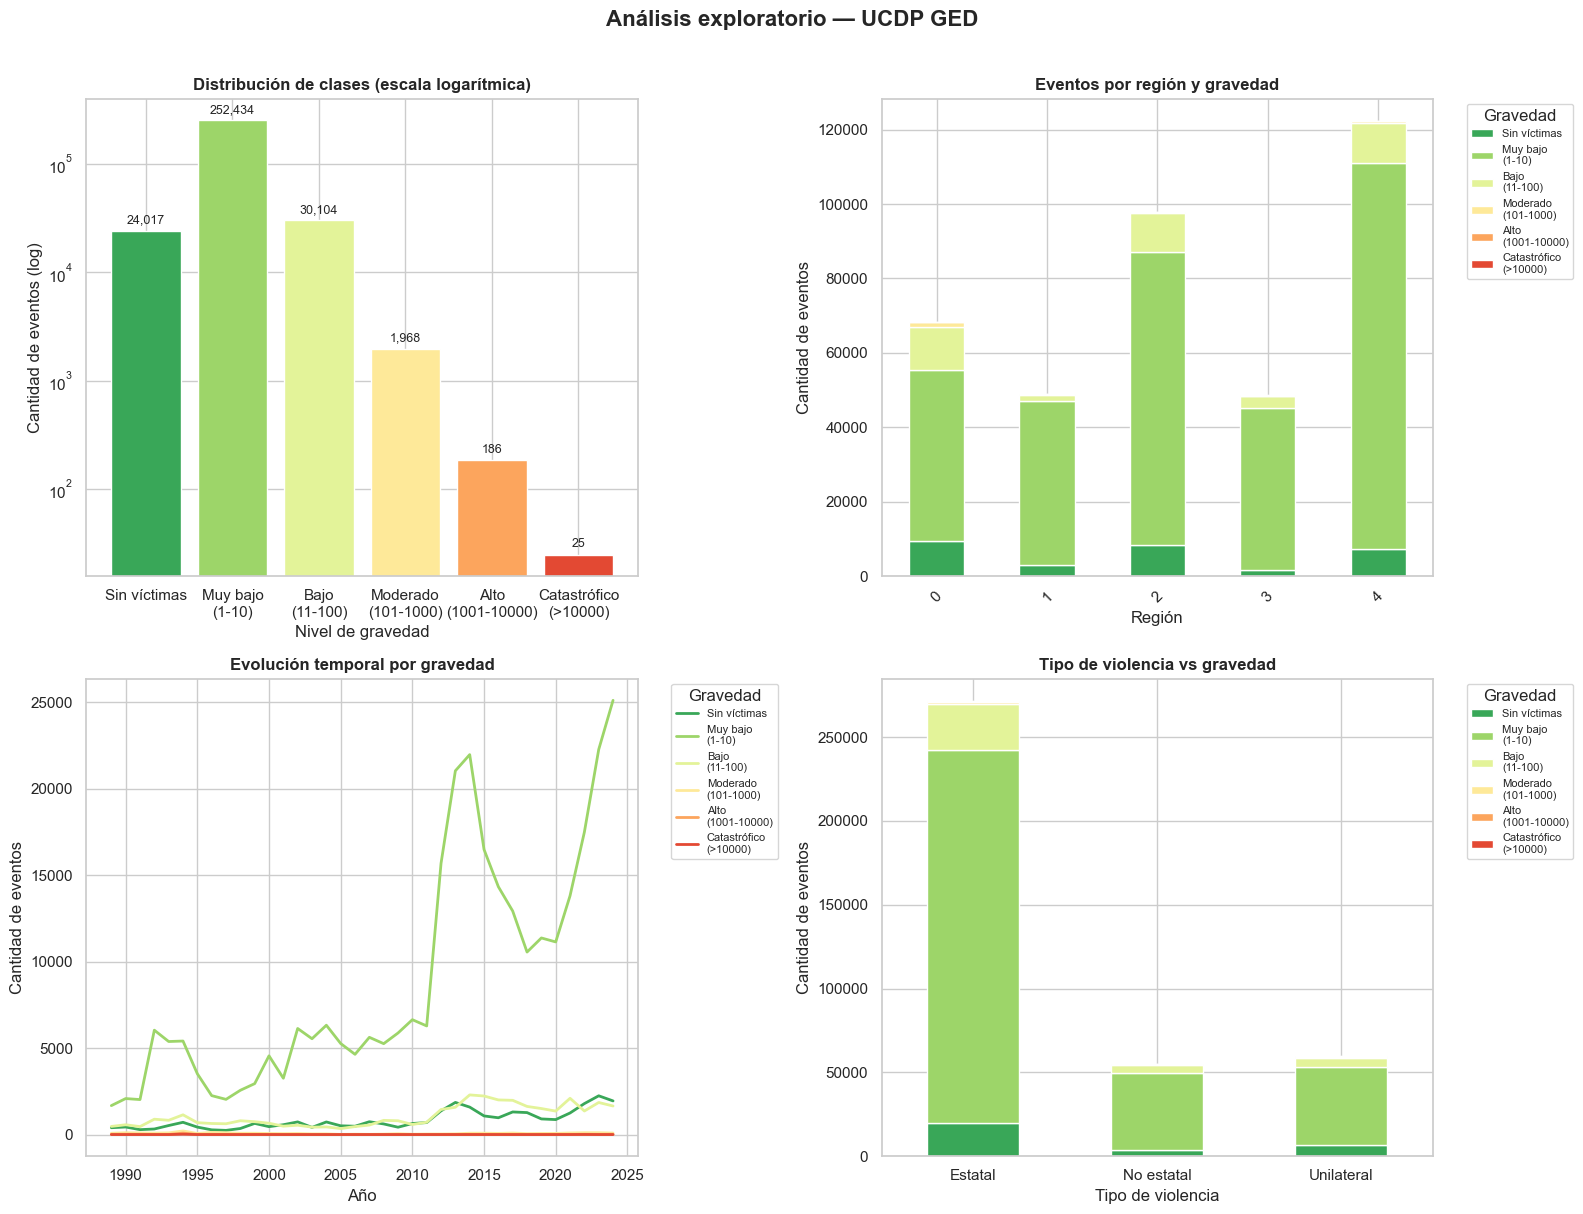

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Paleta y estilo general
sns.set_theme(style="whitegrid")
palette = sns.color_palette("RdYlGn_r", 6)

etiquetas = {
    0: 'Sin víctimas',
    1: 'Muy bajo\n(1-10)',
    2: 'Bajo\n(11-100)',
    3: 'Moderado\n(101-1000)',
    4: 'Alto\n(1001-10000)',
    5: 'Catastrófico\n(>10000)'
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Análisis exploratorio — UCDP GED', fontsize=16, fontweight='bold', y=1.01)

# --- Gráfico 1: Distribución de clases (escala log) ---
ax1 = axes[0, 0]
conteos = y_train.value_counts().sort_index()
bars = ax1.bar(
    [etiquetas[i] for i in conteos.index],
    conteos.values,
    color=palette
)
ax1.set_yscale('log')
ax1.set_title('Distribución de clases (escala logarítmica)', fontweight='bold')
ax1.set_xlabel('Nivel de gravedad')
ax1.set_ylabel('Cantidad de eventos (log)')
for bar, val in zip(bars, conteos.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
             f'{val:,}', ha='center', va='bottom', fontsize=9)

# --- Gráfico 2: Eventos por región ---
ax2 = axes[0, 1]
region_gravedad = df_GEDEvent_model.groupby(['region', 'gravedad']).size().unstack(fill_value=0)
region_gravedad.columns = [etiquetas[c] for c in region_gravedad.columns]
region_gravedad.plot(kind='bar', stacked=True, ax=ax2, 
                     color=palette, legend=True)
ax2.set_title('Eventos por región y gravedad', fontweight='bold')
ax2.set_xlabel('Región')
ax2.set_ylabel('Cantidad de eventos')
ax2.tick_params(axis='x', rotation=45)
ax2.legend(title='Gravedad', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

# --- Gráfico 3: Evolución temporal ---
ax3 = axes[1, 0]
temporal = df_GEDEvent_model.groupby(['year', 'gravedad']).size().unstack(fill_value=0)
temporal.columns = [etiquetas[c] for c in temporal.columns]
temporal.plot(ax=ax3, color=palette, linewidth=2)
ax3.set_title('Evolución temporal por gravedad', fontweight='bold')
ax3.set_xlabel('Año')
ax3.set_ylabel('Cantidad de eventos')
ax3.legend(title='Gravedad', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

# --- Gráfico 4: Tipo de violencia vs gravedad ---
ax4 = axes[1, 1]
tipo_labels = {1: 'Estatal', 2: 'No estatal', 3: 'Unilateral'}
df_GEDEvent_model['tipo_label'] = df_GEDEvent_model['type_of_violence'].map(tipo_labels)
tipo_gravedad = df_GEDEvent_model.groupby(['tipo_label', 'gravedad']).size().unstack(fill_value=0)
tipo_gravedad.columns = [etiquetas[c] for c in tipo_gravedad.columns]
tipo_gravedad.plot(kind='bar', stacked=True, ax=ax4, color=palette)
ax4.set_title('Tipo de violencia vs gravedad', fontweight='bold')
ax4.set_xlabel('Tipo de violencia')
ax4.set_ylabel('Cantidad de eventos')
ax4.tick_params(axis='x', rotation=0)
ax4.legend(title='Gravedad', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('eda_ucdp.png', dpi=150, bbox_inches='tight')
plt.show()

### Balanceo de Clases

A simple vista (En el primer gráfico) podemos ver como la variable target está MUY desbalanceada (considerar que el gráfico está en escala logarítmica).

Por ende, tenemos que someter al coonjunto de entrenamiento a un proceso de balanceo, esto permite que la cantidad de ocurrencias de cada una de las clases sea la misma, evitando que el modelo tenga mas preferencia por una que con la otra.

Para ello, utilizaremos SMOTE (Synthetic Minority Over-sampling Technique), es decir, una técnica de Oversampli que permite duplicar o recrear en forma sintética las muestras de la clase minoritaria

In [19]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# SMOTE
smote = SMOTE(random_state=42, k_neighbors=2, sampling_strategy='auto')
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Distribución después del balanceo:")
print(Counter(y_train_bal))

Distribución después del balanceo:
Counter({1: 252434, 0: 252434, 2: 252434, 3: 252434, 4: 252434, 5: 252434})


### Grafico post Balanceo

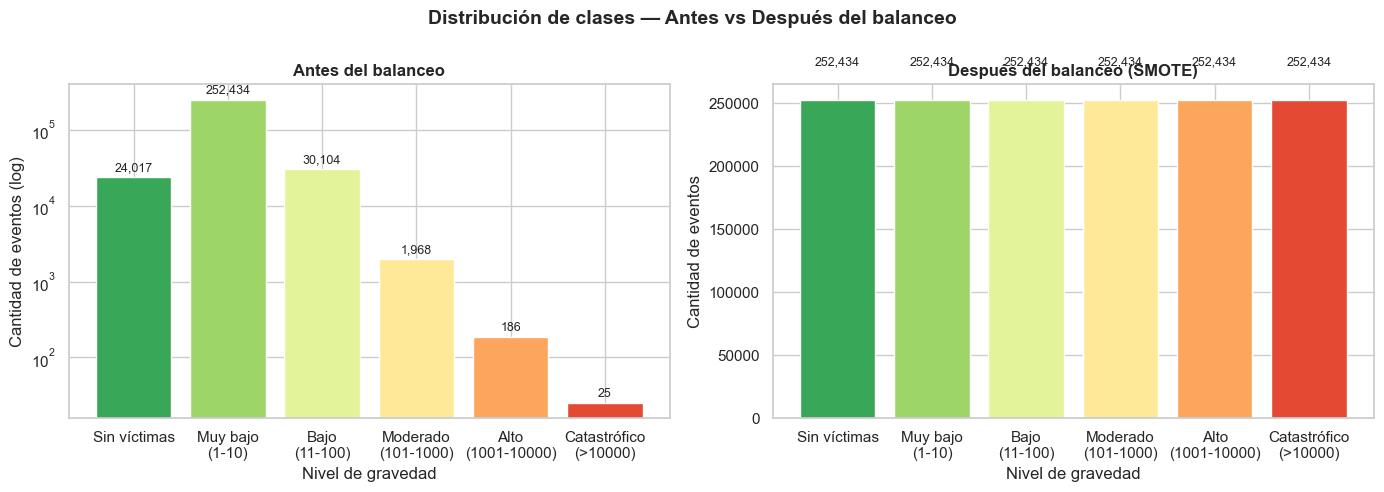

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de clases — Antes vs Después del balanceo', 
             fontsize=14, fontweight='bold')

palette = sns.color_palette("RdYlGn_r", 6)
etiquetas = {
    0: 'Sin víctimas',
    1: 'Muy bajo\n(1-10)',
    2: 'Bajo\n(11-100)',
    3: 'Moderado\n(101-1000)',
    4: 'Alto\n(1001-10000)',
    5: 'Catastrófico\n(>10000)'
}

# --- Antes del balanceo ---
ax1 = axes[0]
conteos_antes = y_train.value_counts().sort_index()
bars1 = ax1.bar(
    [etiquetas[i] for i in conteos_antes.index],
    conteos_antes.values,
    color=palette
)
ax1.set_yscale('log')
ax1.set_title('Antes del balanceo', fontweight='bold')
ax1.set_xlabel('Nivel de gravedad')
ax1.set_ylabel('Cantidad de eventos (log)')
for bar, val in zip(bars1, conteos_antes.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
             f'{val:,}', ha='center', va='bottom', fontsize=9)

# --- Después del balanceo ---
ax2 = axes[1]
conteos_despues = pd.Series(y_train_bal).value_counts().sort_index()
bars2 = ax2.bar(
    [etiquetas[i] for i in conteos_despues.index],
    conteos_despues.values,
    color=palette
)
ax2.set_title('Después del balanceo (SMOTE)', fontweight='bold')
ax2.set_xlabel('Nivel de gravedad')
ax2.set_ylabel('Cantidad de eventos')
for bar, val in zip(bars2, conteos_despues.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
             f'{val:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('balanceo_smote.png', dpi=150, bbox_inches='tight')
plt.show()

### Selección de Features

Lo próximo que voy a hacer es aplicar técnicas para decidir cuales son las features mas relevantes. 

Sabiendo que mi variable target es del tipo "Categórica Ordinal" los test que puedo aplicar son: Información Mutua, Anova y Kruskal-Wallis.

In [21]:
from sklearn.feature_selection import mutual_info_classif, f_classif
from scipy.stats import kruskal

features = X_train_bal.columns.tolist()
y = y_train_bal

# --- Información Mutua ---
mi_scores = mutual_info_classif(X_train_bal, y, random_state=42)

# --- ANOVA F-score + p-value ---
f_scores, p_values = f_classif(X_train_bal, y)

# --- Kruskal-Wallis ---
kruskal_scores = []
kruskal_pvalues = []
for col in features:
    grupos = [X_train_bal[col][y == clase].values for clase in sorted(y.unique())]
    stat, pval = kruskal(*grupos)
    kruskal_scores.append(stat)
    kruskal_pvalues.append(pval)

# --- DataFrame con valores crudos y p-values ---
df_scores = pd.DataFrame({
    'Info. Mutua':       mi_scores,
    'ANOVA F-score':     f_scores,
    'ANOVA p-value':     p_values,
    'Kruskal-Wallis':    kruskal_scores,
    'Kruskal p-value':   kruskal_pvalues,
}, index=features).sort_values('Info. Mutua', ascending=False)

# Indicar si es significativo
df_scores['ANOVA significativo']   = df_scores['ANOVA p-value'] < 0.05
df_scores['Kruskal significativo'] = df_scores['Kruskal p-value'] < 0.05

print(df_scores)

                      Info. Mutua  ANOVA F-score  ANOVA p-value  \
longitude                0.731833    6153.470417            0.0   
latitude                 0.705974   48559.904324            0.0   
frecuencia_conflicto     0.640064   17551.927453            0.0   
priogrid_gid             0.604428   20436.325289            0.0   
side_a_new_id            0.550061   18198.820082            0.0   
country                  0.532648   25571.032626            0.0   
year                     0.494645   50922.471257            0.0   
side_b_new_id            0.478460   26302.077335            0.0   
dyad_new_id              0.459399   15902.413509            0.0   
duracion_dias            0.395102   41073.769305            0.0   
conflict_new_id          0.352843   28269.876031            0.0   
number_of_sources        0.303609   42861.318746            0.0   
date_prec                0.298001  168968.043202            0.0   
where_prec               0.257673   14640.843866            0.

El resultado obtenido es interesante, ya que todos los p-values son cero.
Esto no significa que el p-value sea literalmente cero, sino que es extremadamente pequeño, tan pequeño que Python lo redondea a 0.0. 

Esto es común cuando:
 - El dataset es muy grande — con ~250.000 filas tras el SMOTE, cualquier diferencia mínima entre grupos se vuelve estadísticamente significativa. Esto se llama el problema de la significancia espuria.
 - El balanceo con SMOTE amplificó las diferencias entre clases al generar muestras sintéticas.


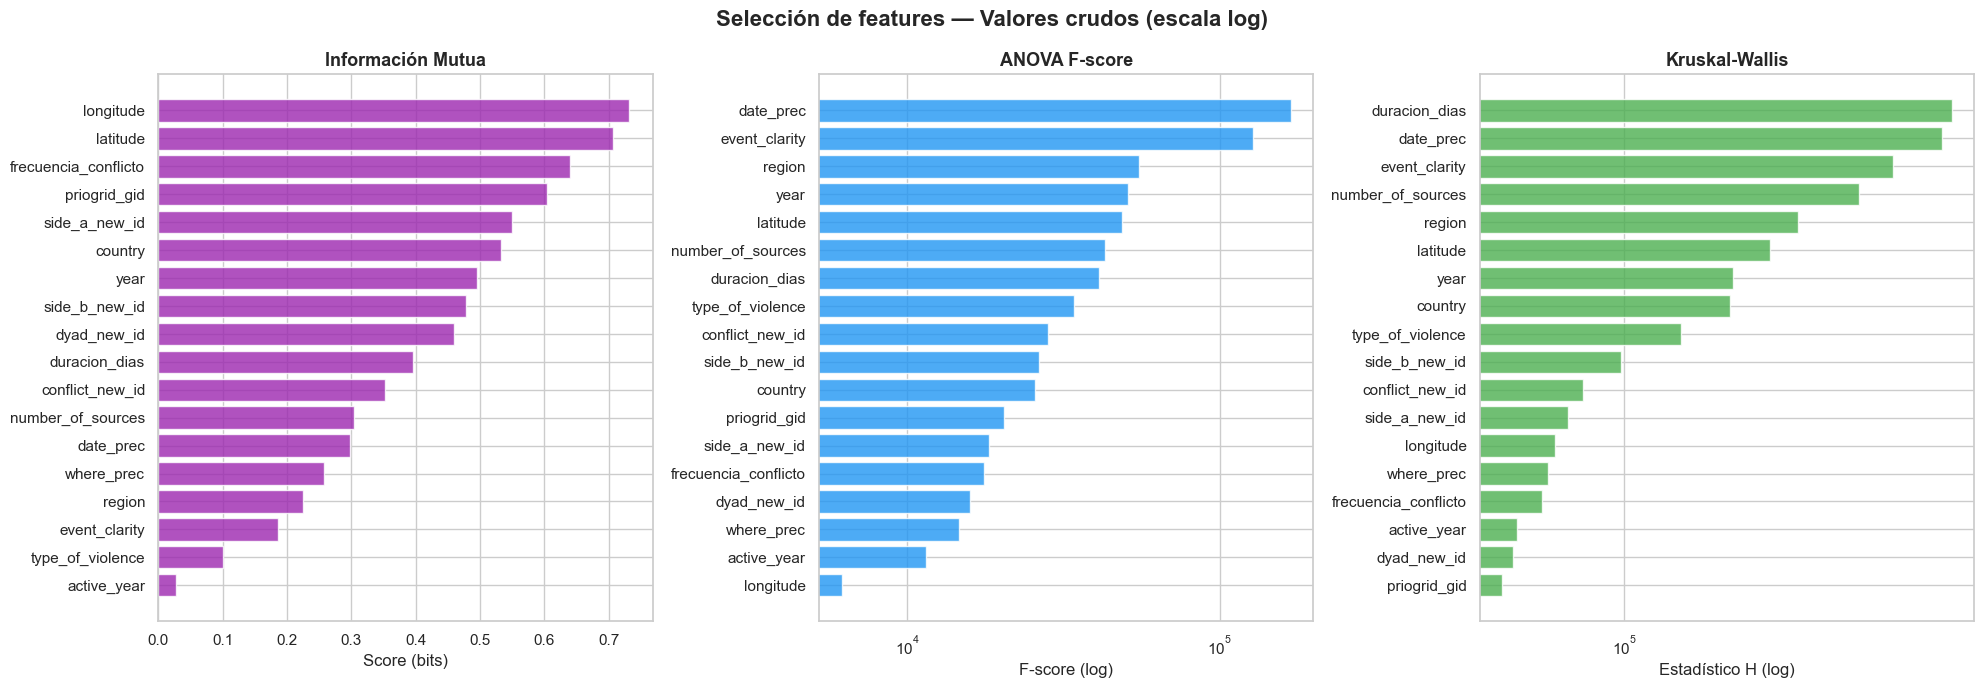

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Selección de features — Valores crudos (escala log)', 
             fontsize=16, fontweight='bold')

# --- Info. Mutua ---
ax = axes[0]
df_sorted = df_scores.sort_values('Info. Mutua', ascending=True)
bars = ax.barh(df_sorted.index, df_sorted['Info. Mutua'], 
               color='#9C27B0', alpha=0.8)
ax.set_title('Información Mutua', fontweight='bold', fontsize=13)
ax.set_xlabel('Score (bits)')

# --- ANOVA F-score ---
ax = axes[1]
df_sorted = df_scores.sort_values('ANOVA F-score', ascending=True)
colores_anova = ['#2196F3' if sig else '#BBDEFB' 
                 for sig in df_sorted['ANOVA significativo']]
bars = ax.barh(df_sorted.index, df_sorted['ANOVA F-score'],
               color=colores_anova, alpha=0.8)
ax.set_xscale('log')
ax.set_title('ANOVA F-score', fontweight='bold', fontsize=13)
ax.set_xlabel('F-score (log)')

# --- Kruskal-Wallis ---
ax = axes[2]
df_sorted = df_scores.sort_values('Kruskal-Wallis', ascending=True)
colores_kruskal = ['#4CAF50' if sig else '#C8E6C9' 
                   for sig in df_sorted['Kruskal significativo']]
bars = ax.barh(df_sorted.index, df_sorted['Kruskal-Wallis'],
               color=colores_kruskal, alpha=0.8)
ax.set_xscale('log')
ax.set_title('Kruskal-Wallis', fontweight='bold', fontsize=13)
ax.set_xlabel('Estadístico H (log)')

plt.tight_layout()
plt.savefig('feature_selection_crudos.png', dpi=150, bbox_inches='tight')
plt.show()